# Person C assignment: genre and movie analysis

Genre-level rating and popularity patterns for MovieLens-20M, built on the leader's shared tables (`movie_stats`, `exploded_genres`, `rating_genre_df`). Covers the required genre summary, Challenge Question 1 (top genre by rating, before/after a movie-level support filter), single- vs. multi-genre comparisons, genre-pair analysis with Challenge Question 5, and decade-level genre prominence.

In [1]:
from pathlib import Path
import os
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / 'load_data.py').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from load_data import load_movielens
from preprocess import build_shared_tables
from plotting import save_figure

data_dir = Path(os.environ.get('MOVIELENS_DATA_DIR', PROJECT_ROOT / 'data' / 'ml-20m'))
frames = load_movielens(data_dir, include_optional=False)  # this notebook only needs ratings.csv/movies.csv; skip tags/links/genome to save memory and load time
tables = build_shared_tables(frames['ratings'], frames['movies'], frames.get('tags'))
ratings = tables['ratings']
movies = tables['movies']
movie_stats = tables['movie_stats']
exploded_genres = tables['exploded_genres']
rating_genre_df = tables['rating_genre_df']
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'summary_tables'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Part A — genre summary and Challenge Question 1

**Question.** For each genre: movie count, rating count, mean, median, standard deviation, and variance of its ratings. Which genre has the highest average rating — and does the answer change once very-low-support movies are excluded?

**Data and columns.** `exploded_genres` (`movieId`, `genre`) for unique movie counts per genre; `rating_genre_df` (`movieId`, `genre`, `rating`) for rating-level statistics — a multi-genre movie's ratings are counted once per genre it carries; `movie_stats` (`movieId`, `rating_count`) to apply the shared Challenge Question 1 support rule.

**Method.** Group `exploded_genres` by `genre` for movie counts, and `rating_genre_df` by `genre` for rating count, mean, median, standard deviation, and variance — together this is `genre_stats`. For Challenge Question 1, repeat the rating-level aggregation twice: once on every rating ("before"), and once restricted to ratings on movies whose own `rating_count` in `movie_stats` is at least 1000 ("after") — the shared support rule from `README.md`. A genre only has an "after" value if at least one of its movies clears that threshold.

In [2]:
# --- genre_stats: movie count, rating count, and rating statistics per genre ---
genre_movie_counts = (
    exploded_genres.groupby('genre', as_index=False)['movieId']
    .nunique()
    .rename(columns={'movieId': 'movie_count'})
)
genre_rating_stats = (
    rating_genre_df.groupby('genre')['rating']
    .agg(rating_count='size', mean_rating='mean', median_rating='median',
         std_rating='std', var_rating='var')
    .reset_index()
)
genre_stats = (
    genre_movie_counts.merge(genre_rating_stats, on='genre', how='left')
    .sort_values('mean_rating', ascending=False)
    .reset_index(drop=True)
)
genre_stats.to_csv(OUTPUT_DIR / 'genre_stats.csv', index=False)
display(genre_stats)

,genre,movie_count,rating_count,mean_rating,median_rating,std_rating,var_rating
0,Film-Noir,330,216689,3.965381,4.0,0.895467,0.801861
1,War,1194,1048618,3.809531,4.0,0.984262,0.968773
2,Documentary,2471,244619,3.739718,4.0,1.002614,1.005234
3,Crime,2939,3298335,3.674528,4.0,1.003384,1.006779
4,Drama,13344,8857853,3.674296,4.0,0.990180,0.980456
5,Mystery,1514,1557282,3.663509,4.0,1.000537,1.001075
6,IMAX,196,492366,3.655946,4.0,0.979860,0.960126
7,Animation,1027,1140476,3.617494,4.0,1.006709,1.013462
8,Western,676,423714,3.570498,4.0,1.016100,1.032460
9,Musical,1036,870915,3.558091,4.0,1.049020,1.100443


In [3]:
# --- Challenge Question 1: top genre by mean rating, before/after the movie-support filter ---
MIN_MOVIE_RATING_COUNT_Q1 = 1000  # shared rule: movies need >= this many ratings to count "after"

qualifying_movie_ids = set(
    movie_stats.loc[movie_stats['rating_count'] >= MIN_MOVIE_RATING_COUNT_Q1, 'movieId']
)
filtered_rating_genre_df = rating_genre_df[rating_genre_df['movieId'].isin(qualifying_movie_ids)]

after_rating_stats = (
    filtered_rating_genre_df.groupby('genre')['rating']
    .agg(rating_count_after='size', mean_rating_after='mean')
    .reset_index()
)
after_movie_counts = (
    filtered_rating_genre_df.groupby('genre')['movieId']
    .nunique()
    .rename('movie_count_after')
    .reset_index()
)

q1_genre_comparison = genre_stats[['genre', 'movie_count', 'rating_count', 'mean_rating']].rename(
    columns={
        'movie_count': 'movie_count_before',
        'rating_count': 'rating_count_before',
        'mean_rating': 'mean_rating_before',
    }
)
q1_genre_comparison = (
    q1_genre_comparison.merge(after_movie_counts, on='genre', how='left')
    .merge(after_rating_stats, on='genre', how='left')
)
q1_genre_comparison['movie_count_after'] = q1_genre_comparison['movie_count_after'].fillna(0).astype(int)
q1_genre_comparison['rating_count_after'] = q1_genre_comparison['rating_count_after'].fillna(0).astype(int)
q1_genre_comparison['rank_before'] = (
    q1_genre_comparison['mean_rating_before'].rank(ascending=False, method='min').astype(int)
)
has_after = q1_genre_comparison['movie_count_after'] > 0
q1_genre_comparison.loc[has_after, 'rank_after'] = (
    q1_genre_comparison.loc[has_after, 'mean_rating_after'].rank(ascending=False, method='min')
)
q1_genre_comparison = q1_genre_comparison.sort_values('rank_before').reset_index(drop=True)
q1_genre_comparison.to_csv(OUTPUT_DIR / 'q1_genre_comparison.csv', index=False)
display(q1_genre_comparison)

top_before = q1_genre_comparison.iloc[0]
after_eligible = q1_genre_comparison[q1_genre_comparison['movie_count_after'] > 0]
if not after_eligible.empty:
    top_after = after_eligible.sort_values('mean_rating_after', ascending=False).iloc[0]
    print(
        f"Challenge Question 1 -- before the >= {MIN_MOVIE_RATING_COUNT_Q1}-rating filter, "
        f"'{top_before['genre']}' has the highest average rating "
        f"({top_before['mean_rating_before']:.3f}, n={int(top_before['rating_count_before'])} ratings). "
        f"After the filter, '{top_after['genre']}' leads "
        f"({top_after['mean_rating_after']:.3f}, n={int(top_after['movie_count_after'])} qualifying movies, "
        f"{int(top_after['rating_count_after'])} ratings)."
    )
else:
    print(f"Challenge Question 1 -- no genre has a movie meeting the >= {MIN_MOVIE_RATING_COUNT_Q1}-rating threshold.")

,genre,movie_count_before,rating_count_before,mean_rating_before,movie_count_after,rating_count_after,mean_rating_after,rank_before,rank_after
0,Film-Noir,330,216689,3.965381,36,192295,4.001001,1,1.0
1,War,1194,1048618,3.809531,149,953184,3.843530,2,2.0
2,Documentary,2471,244619,3.739718,53,133567,3.829767,3,3.0
3,Crime,2939,3298335,3.674528,450,3036044,3.710999,4,5.0
4,Drama,13344,8857853,3.674296,1493,7775787,3.711583,5,4.0
5,Mystery,1514,1557282,3.663509,243,1438907,3.697094,6,6.0
6,IMAX,196,492366,3.655946,75,457232,3.693438,7,7.0
7,Animation,1027,1140476,3.617494,169,1055121,3.646132,8,8.0
8,Western,676,423714,3.570498,65,381620,3.600903,9,9.0
9,Musical,1036,870915,3.558091,133,785924,3.588766,10,10.0


Challenge Question 1 -- before the >= 1000-rating filter, 'Film-Noir' has the highest average rating (3.965, n=216689 ratings). After the filter, 'Film-Noir' leads (4.001, n=36 qualifying movies, 192295 ratings).


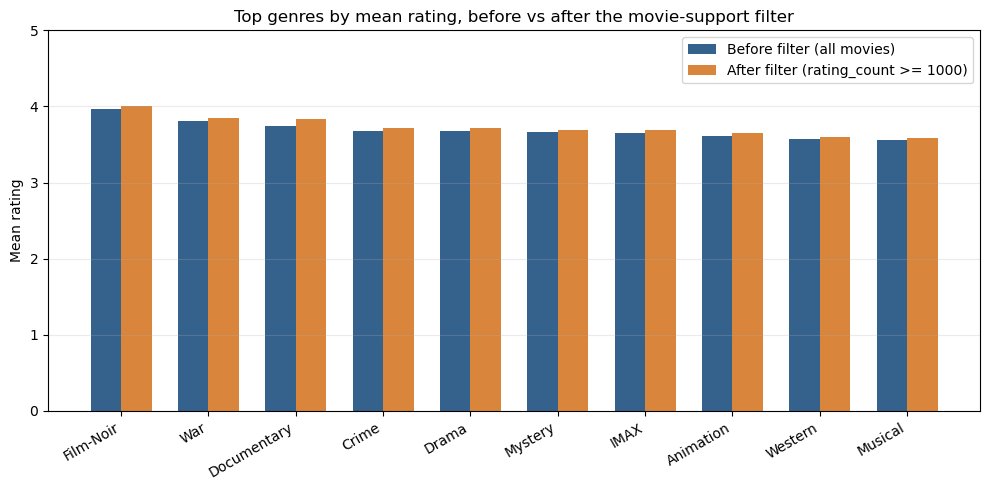

In [4]:
# --- top-genre figure: mean rating before vs after the support filter ---
top10 = q1_genre_comparison.sort_values('mean_rating_before', ascending=False).head(10)
x = np.arange(len(top10))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, top10['mean_rating_before'], width, label='Before filter (all movies)', color='#35618d')
ax.bar(x + width / 2, top10['mean_rating_after'], width,
       label=f'After filter (rating_count >= {MIN_MOVIE_RATING_COUNT_Q1})', color='#d9853b')
ax.set_xticks(x)
ax.set_xticklabels(top10['genre'], rotation=30, ha='right')
ax.set_ylabel('Mean rating')
ax.set_title('Top genres by mean rating, before vs after the movie-support filter')
ax.set_ylim(0, 5)
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
save_figure(fig, FIGURE_DIR / 'genre_q1_before_after.png')
plt.show()

**Interpretation.** The printed answer above names the top genre before and after the filter, with its exact support (`rating_count`/`movie_count`). If the identity of the top genre changes between the two, that illustrates the review trap directly: a small handful of highly-rated but rarely-rated movies can push a genre's raw average up in a way a stricter, more-popular-movie filter reverses.

**Limitation.** Genre-level rating means here are inflated relative to a "typical movie" figure because a multi-genre movie's ratings are duplicated across every genre it lists (quantified in Part B). The `rating_count >= 1000` rule is the assignment's fixed support threshold, not something chosen for this analysis — a different cutoff could produce a different "after" answer, and neither number explains *why* a genre rates higher, only that it does under this definition.

## Part B — single- versus multi-genre movies

**Question.** Do movies with more listed genres tend to be rated, or popular, differently than movies with fewer genres?

**Data and columns.** `movie_stats` (`movieId`, `genre_count`, `avg_rating`, `rating_count`) — movie-level, so unlike Part A each movie is counted once regardless of how many genres it lists, and there is no genre-duplication effect here.

**Method.** Exclude movies with `genre_count == 0` (no genre listed, per the shared definitions). Group the rest by `genre_count` (capped at 5+ for readability) and report movie count, mean/median `avg_rating`, and mean/median `rating_count` (popularity) per group. A group's `genre_group` label is `single` when `genre_count == 1` and `multi` otherwise, so the single-vs-multi comparison is just this table viewed at that coarser level.

In [5]:
# --- single- vs multi-genre and genre_count analysis ---
GENRE_COUNT_CAP = 5  # movies with 5+ genres are grouped together for readability

scoped_movies = movie_stats.loc[movie_stats['genre_count'].fillna(0) > 0].copy()
scoped_movies['genre_count_capped'] = scoped_movies['genre_count'].clip(upper=GENRE_COUNT_CAP)

multigenre_comparison = (
    scoped_movies.groupby('genre_count_capped')
    .agg(
        movie_count=('movieId', 'size'),
        mean_avg_rating=('avg_rating', 'mean'),
        median_avg_rating=('avg_rating', 'median'),
        mean_rating_count=('rating_count', 'mean'),
        median_rating_count=('rating_count', 'median'),
    )
    .reset_index()
    .rename(columns={'genre_count_capped': 'genre_count'})
)
multigenre_comparison['genre_group'] = np.where(multigenre_comparison['genre_count'] == 1, 'single', 'multi')
multigenre_comparison.to_csv(OUTPUT_DIR / 'multigenre_comparison.csv', index=False)
display(multigenre_comparison)

single_vs_multi = (
    scoped_movies.assign(genre_group=np.where(scoped_movies['genre_count'] == 1, 'single', 'multi'))
    .groupby('genre_group')
    .agg(movie_count=('movieId', 'size'), mean_avg_rating=('avg_rating', 'mean'), mean_rating_count=('rating_count', 'mean'))
)
display(single_vs_multi)

,genre_count,movie_count,mean_avg_rating,median_avg_rating,mean_rating_count,median_rating_count,genre_group
0,1,10583,3.170744,3.267857,319.166021,9.0,single
1,2,8809,3.110251,3.202703,678.981950,22.0,multi
2,3,5330,3.102119,3.193005,1185.550094,28.0,multi
3,4,1724,3.146102,3.202279,1775.504060,86.0,multi
4,5,586,3.187820,3.278595,2151.988055,122.0,multi


,movie_count,mean_avg_rating,mean_rating_count
genre_group,,,
multi,16449,3.114137,1010.527570
single,10583,3.170744,319.166021


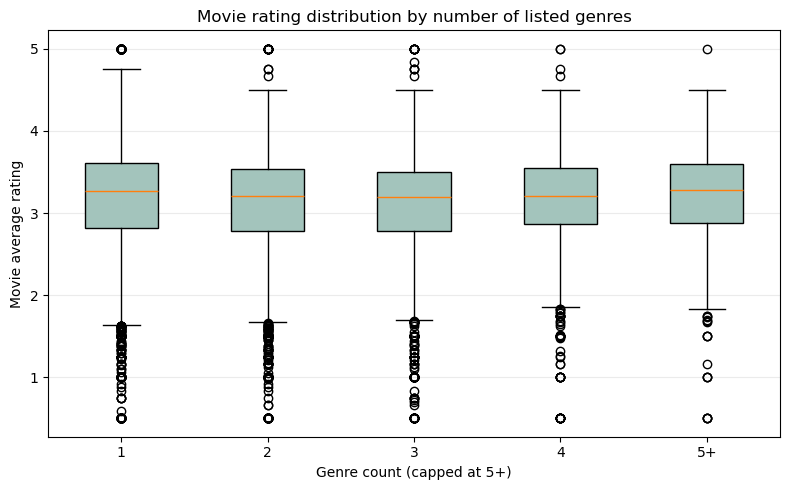

In [6]:
# --- rating-distribution figure: movie rating spread by genre_count ---
fig, ax = plt.subplots(figsize=(8, 5))
groups = sorted(scoped_movies['genre_count_capped'].unique())
box_data = [scoped_movies.loc[scoped_movies['genre_count_capped'] == g, 'avg_rating'].dropna() for g in groups]
box_labels = [f'{int(g)}+' if g == GENRE_COUNT_CAP else str(int(g)) for g in groups]
ax.boxplot(box_data, patch_artist=True, boxprops={'facecolor': '#a3c4bc'})
ax.set_xticks(range(1, len(groups) + 1))
ax.set_xticklabels(box_labels)
ax.set_xlabel(f'Genre count (capped at {GENRE_COUNT_CAP}+)')
ax.set_ylabel('Movie average rating')
ax.set_title('Movie rating distribution by number of listed genres')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
save_figure(fig, FIGURE_DIR / 'genre_rating_distribution_by_count.png')
plt.show()

**Interpretation.** Compare `mean_avg_rating` and `mean_rating_count` across `genre_count` in the table above: a flat pattern means genre breadth has little relationship with how a movie is rated or how popular it is; a rising or falling trend suggests one. The boxplot shows whether that relationship holds up across the full rating distribution, not just the mean.

**Limitation.** This section intentionally does *not* use `rating_genre_df` or `exploded_genres` — the point is to measure each movie once. Anyone reusing Part A's genre-level tables for a "does genre X get rated higher" question must remember that a movie's ratings appear once per genre it lists, so those cross-genre totals double-count multi-genre movies by design; this section is the reference point for how big that duplication effect is (compare each `movie_count` here with the `movie_count`/`rating_count` implied by `genre_stats`).

## Part C — genre pairs and Challenge Question 5

**Question.** Do specific genre *combinations* rate higher or lower than either of their component genres alone? Which combinations are worth highlighting, and which have too few movies to trust?

**Data and columns.** `movies` (`movieId`, `genre_list`) to build every unordered genre pair a movie actually carries; `ratings` (`movieId`, `rating`) joined onto those pairs for rating-level statistics; `genre_stats` from Part A as the single-genre comparison baseline.

**Method.** For every movie with 2+ genres, generate all `itertools.combinations` of the genres it carries, taken two at a time. Join those (movie, pair) rows to `ratings` and aggregate by pair: movie count (support), rating count, mean, and standard deviation. Apply a minimum-support rule of `MIN_PAIR_SUPPORT` movies; pairs below it stay in the exported table for transparency but are excluded from the comparison and from Challenge Question 5. For qualifying pairs, `rating_gain` is the pair's mean rating minus the *average* of its two component genres' own mean ratings (from `genre_stats`) — a positive gain means the combination rates higher than either genre typically does alone.

In [7]:
# --- build every genre pair each movie belongs to, then rating-level stats per pair ---
MIN_PAIR_SUPPORT = 100  # a pair needs at least this many movies before its rating is trusted

pair_rows = []
for row in movies.loc[movies['genre_count'] >= 2, ['movieId', 'genre_list']].itertuples(index=False):
    for genre_a, genre_b in itertools.combinations(sorted(set(row.genre_list)), 2):
        pair_rows.append({'movieId': row.movieId, 'genre_a': genre_a, 'genre_b': genre_b})
pair_movies = pd.DataFrame(pair_rows, columns=['movieId', 'genre_a', 'genre_b'])

pair_ratings = pair_movies.merge(ratings[['movieId', 'rating']], on='movieId', how='left')
genre_pair_stats = (
    pair_ratings.groupby(['genre_a', 'genre_b'])
    .agg(
        pair_movie_count=('movieId', 'nunique'),
        pair_rating_count=('rating', 'size'),
        pair_mean_rating=('rating', 'mean'),
        pair_std_rating=('rating', 'std'),
    )
    .reset_index()
)

single_lookup = genre_stats[['genre', 'movie_count', 'mean_rating']].rename(
    columns={'movie_count': 'genre_movie_count', 'mean_rating': 'genre_mean_rating'}
)
genre_pair_stats = genre_pair_stats.merge(
    single_lookup.rename(columns={'genre': 'genre_a', 'genre_movie_count': 'genre_a_movie_count', 'genre_mean_rating': 'genre_a_mean_rating'}),
    on='genre_a', how='left',
)
genre_pair_stats = genre_pair_stats.merge(
    single_lookup.rename(columns={'genre': 'genre_b', 'genre_movie_count': 'genre_b_movie_count', 'genre_mean_rating': 'genre_b_mean_rating'}),
    on='genre_b', how='left',
)
genre_pair_stats['mean_individual_rating'] = genre_pair_stats[['genre_a_mean_rating', 'genre_b_mean_rating']].mean(axis=1)
genre_pair_stats['rating_gain'] = genre_pair_stats['pair_mean_rating'] - genre_pair_stats['mean_individual_rating']
genre_pair_stats['meets_min_support'] = genre_pair_stats['pair_movie_count'] >= MIN_PAIR_SUPPORT
genre_pair_stats = genre_pair_stats.sort_values('pair_movie_count', ascending=False).reset_index(drop=True)
genre_pair_stats.to_csv(OUTPUT_DIR / 'genre_pair_stats.csv', index=False)
display(genre_pair_stats.head(15))

qualifying_pairs = genre_pair_stats[genre_pair_stats['meets_min_support']].sort_values('rating_gain', ascending=False)
print(f'{len(qualifying_pairs)} of {len(genre_pair_stats)} pairs meet the >= {MIN_PAIR_SUPPORT}-movie support rule.')
if not qualifying_pairs.empty:
    best = qualifying_pairs.iloc[0]
    worst = qualifying_pairs.iloc[-1]
    print(
        f"Challenge Question 5 -- among pairs with >= {MIN_PAIR_SUPPORT} movies, "
        f"'{best['genre_a']} + {best['genre_b']}' has the largest positive gain "
        f"({best['rating_gain']:+.3f} vs. its components' average, n={int(best['pair_movie_count'])} movies), "
        f"while '{worst['genre_a']} + {worst['genre_b']}' has the largest negative gain "
        f"({worst['rating_gain']:+.3f}, n={int(worst['pair_movie_count'])} movies)."
    )
else:
    print(f'Challenge Question 5 -- no genre pair reaches the >= {MIN_PAIR_SUPPORT}-movie support rule.')

,genre_a,genre_b,pair_movie_count,pair_rating_count,pair_mean_rating,pair_std_rating,genre_a_movie_count,genre_a_mean_rating,genre_b_movie_count,genre_b_mean_rating,mean_individual_rating,rating_gain,meets_min_support
0,Drama,Romance,2573,2092583,3.629968,1.011349,13344,3.674296,4127,3.541803,3.608049,0.021919,True
1,Comedy,Drama,2546,2047586,3.651309,0.990967,8374,3.426011,13344,3.674296,3.550153,0.101156,True
2,Comedy,Romance,1895,2143445,3.512419,1.025809,8374,3.426011,4127,3.541803,3.483907,0.028513,True
3,Drama,Thriller,1868,1992198,3.593350,0.992406,13344,3.674296,4178,3.507111,3.590703,0.002647,True
4,Crime,Drama,1712,1682667,3.794043,0.951736,2939,3.674528,13344,3.674296,3.674412,0.119631,True
5,Crime,Thriller,1232,1826038,3.673520,0.989635,2939,3.674528,4178,3.507111,3.590819,0.082700,True
6,Action,Drama,1203,1384037,3.617322,1.017677,3520,3.443864,13344,3.674296,3.559080,0.058242,True
7,Action,Thriller,1109,2567311,3.428597,1.023254,3520,3.443864,4178,3.507111,3.475487,-0.046890,True
8,Horror,Thriller,1073,768698,3.234612,1.120296,2611,3.277224,4178,3.507111,3.392168,-0.157555,True
9,Action,Adventure,972,2457548,3.460954,1.056300,3520,3.443864,2329,3.501893,3.472878,-0.011924,True


84 of 168 pairs meet the >= 100-movie support rule.
Challenge Question 5 -- among pairs with >= 100 movies, 'Crime + Horror' has the largest positive gain (+0.285 vs. its components' average, n=161 movies), while 'Comedy + Western' has the largest negative gain (-0.322, n=135 movies).


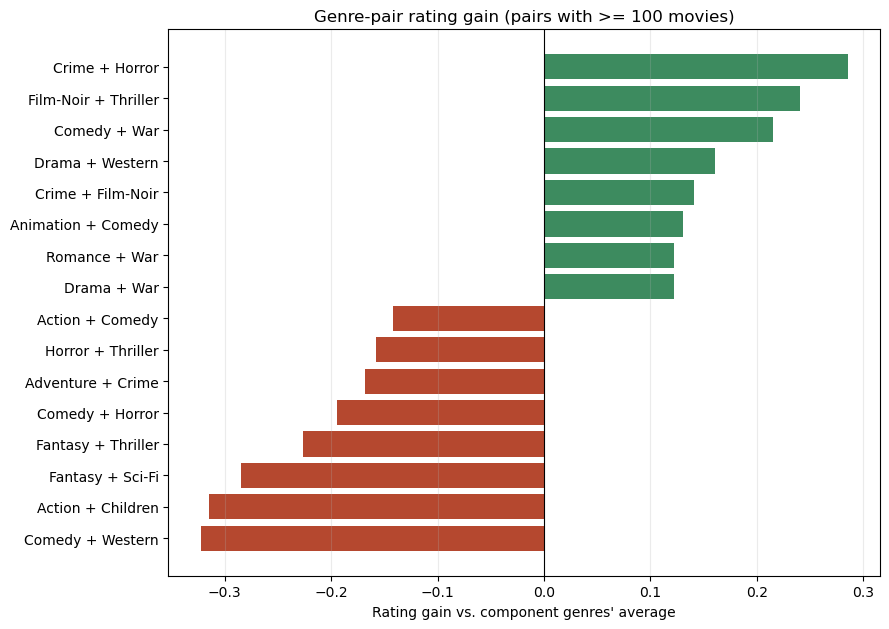

In [8]:
# --- pair-gain figure: qualifying pairs only, biggest gains and losses ---
if not qualifying_pairs.empty:
    to_plot = pd.concat([qualifying_pairs.head(8), qualifying_pairs.tail(8)]).drop_duplicates(['genre_a', 'genre_b'])
    to_plot = to_plot.sort_values('rating_gain')
    labels = to_plot['genre_a'] + ' + ' + to_plot['genre_b']
    colors = np.where(to_plot['rating_gain'] >= 0, '#3d8b5f', '#b5482f')
    fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(to_plot))))
    ax.barh(labels, to_plot['rating_gain'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel("Rating gain vs. component genres' average")
    ax.set_title(f'Genre-pair rating gain (pairs with >= {MIN_PAIR_SUPPORT} movies)')
    ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()
    save_figure(fig, FIGURE_DIR / 'genre_pair_gain.png')
    plt.show()
else:
    print('Skipped the pair-gain figure: no pair meets the minimum-support rule.')

**Interpretation.** `genre_pair_stats.csv` holds every pair so the raw numbers stay auditable, but only rows with `meets_min_support == True` back the printed Challenge Question 5 answer and the figure above; a pair built from only a handful of movies can show a large `rating_gain` purely by chance.

**Limitation.** `MIN_PAIR_SUPPORT` is this analysis's own choice, not a value fixed by the shared contract, and a different threshold could change which pairs qualify. `rating_gain` is a descriptive comparison against each genre's own mean, not a causal claim that combining two genres *causes* a rating change — movies in a given pair may differ from typical genre-A or genre-B movies in other ways (era, studio, budget) that this table cannot separate out.

## Part D — decade genre prominence

**Question.** How has genre prominence shifted between two release decades?

**Data and columns.** `movies` (`movieId`, `release_decade`, `release_year_parse_ok`) to pick decades and their movie totals; `exploded_genres` (`movieId`, `genre`, `release_decade`) for genre movie counts within each decade.

**Method.** Person B's notebook (`01_user_temporal.ipynb`) is where the project's two comparison decades are meant to be chosen (its own Part D); as of this handoff that notebook is still an unimplemented scaffold, so `DECADE_A`/`DECADE_B` below default to the two decades with the most parsed release years — the same "most support" logic a manual choice would reasonably use. **Replace these two variables with Person B's actual decades once that notebook is finished, then re-run this section** — everything below is written to work unchanged for any two decades. Genre prominence is measured as each genre's *share* of that decade's movies, not raw counts, so it is comparable across decades with different total movie counts; because movies can carry more than one genre, shares within a decade do not sum to 100%.

In [9]:
# --- pick two decades (placeholder: most release-year support; align with Person B when available) ---
decade_support = (
    movies.loc[movies['release_year_parse_ok'], 'release_decade']
    .value_counts()
    .sort_values(ascending=False)
)
DECADE_A, DECADE_B = sorted(int(d) for d in decade_support.head(2).index)
print(f'Comparing the {DECADE_A}s and {DECADE_B}s ({decade_support.loc[DECADE_A]} and '
      f'{decade_support.loc[DECADE_B]} movies with a parsed release year, respectively).')

decade_genre = exploded_genres[exploded_genres['release_decade'].isin([DECADE_A, DECADE_B])]
decade_totals = (
    movies[movies['release_decade'].isin([DECADE_A, DECADE_B])]
    .groupby('release_decade')['movieId']
    .nunique()
    .rename('decade_movie_total')
)
prominence = (
    decade_genre.groupby(['release_decade', 'genre'])['movieId']
    .nunique()
    .rename('movie_count')
    .reset_index()
    .merge(decade_totals, on='release_decade', how='left')
)
prominence['movie_share'] = prominence['movie_count'] / prominence['decade_movie_total']

decade_genre_prominence = (
    prominence.pivot(index='genre', columns='release_decade', values='movie_share').fillna(0.0)
)
share_col_a, share_col_b = f'share_{DECADE_A}s', f'share_{DECADE_B}s'
decade_genre_prominence.columns = [f'share_{int(c)}s' for c in decade_genre_prominence.columns]
decade_genre_prominence['share_delta'] = decade_genre_prominence[share_col_b] - decade_genre_prominence[share_col_a]
decade_genre_prominence = decade_genre_prominence.sort_values('share_delta', ascending=False).reset_index()
decade_genre_prominence.to_csv(OUTPUT_DIR / 'decade_genre_prominence.csv', index=False)
display(decade_genre_prominence)

Comparing the 2000s and 2010s (7873 and 4871 movies with a parsed release year, respectively).


,genre,share_2000s,share_2010s,share_delta
0,Documentary,0.129049,0.174297,0.045248
1,IMAX,0.006859,0.024636,0.017777
2,Sci-Fi,0.056268,0.065490,0.009221
3,Animation,0.047123,0.048039,0.000916
4,Western,0.006732,0.006980,0.000248
5,Film-Noir,0.002032,0.002053,0.000021
6,Action,0.134383,0.131185,-0.003199
7,Children,0.041407,0.037980,-0.003427
8,Horror,0.099835,0.094436,-0.005398
9,Adventure,0.077988,0.072264,-0.005724


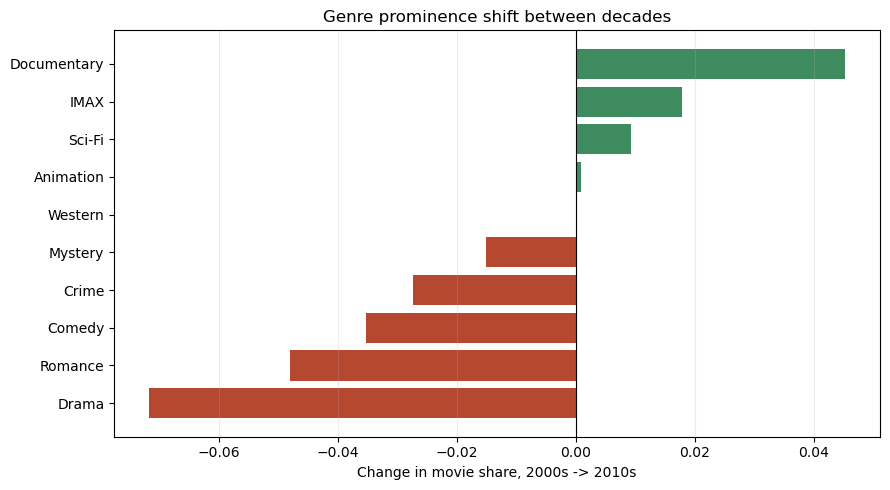

Biggest gainer 2000s -> 2010s: Documentary (12.9% -> 17.4%). Biggest decline: Drama (51.0% -> 43.9%).


In [10]:
# --- decade-prominence figure: biggest gainers and decliners in genre share ---
top_swing = pd.concat([decade_genre_prominence.head(5), decade_genre_prominence.tail(5)]).drop_duplicates('genre')
top_swing = top_swing.sort_values('share_delta')
fig, ax = plt.subplots(figsize=(9, 5))
colors = np.where(top_swing['share_delta'] >= 0, '#3d8b5f', '#b5482f')
ax.barh(top_swing['genre'], top_swing['share_delta'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Change in movie share, {DECADE_A}s -> {DECADE_B}s')
ax.set_title('Genre prominence shift between decades')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
save_figure(fig, FIGURE_DIR / 'genre_decade_prominence.png')
plt.show()

biggest_gain = decade_genre_prominence.iloc[0]
biggest_drop = decade_genre_prominence.iloc[-1]
print(
    f"Biggest gainer {DECADE_A}s -> {DECADE_B}s: {biggest_gain['genre']} "
    f"({biggest_gain[share_col_a]:.1%} -> {biggest_gain[share_col_b]:.1%}). "
    f"Biggest decline: {biggest_drop['genre']} ({biggest_drop[share_col_a]:.1%} -> {biggest_drop[share_col_b]:.1%})."
)

**Interpretation.** A genre's `share_delta` reflects how its slice of *that decade's catalogue* changed, independent of the two decades having different total movie counts. A large swing is a description of what got made and catalogued, not of audience taste or quality.

**Limitation.** `release_year` is parsed from the title string and is missing for a small fraction of movies (see `release_year_parse_rate` in the leader's `runtime_feasibility.csv`), so decade totals slightly undercount the true release-year distribution. The decade choice above is a provisional stand-in for Person B's Part D selection and should be re-run once that notebook fixes the project's actual two decades.

## Findings, limitations, and thresholds

In [11]:
# --- findings and thresholds, generated from the tables computed above ---
findings = []

findings.append(
    f"1. Before any support filter, '{top_before['genre']}' has the highest mean rating "
    f"({top_before['mean_rating_before']:.3f}, n={int(top_before['rating_count_before'])} ratings); "
    + (
        f"after requiring movie rating_count >= {MIN_MOVIE_RATING_COUNT_Q1}, the new leader is "
        f"'{top_after['genre']}' ({top_after['mean_rating_after']:.3f}, n={int(top_after['movie_count_after'])} movies)."
        if not after_eligible.empty else
        f"no genre had a movie clearing the rating_count >= {MIN_MOVIE_RATING_COUNT_Q1} bar."
    )
)
findings.append(
    (
        f"2. Among genre pairs with >= {MIN_PAIR_SUPPORT} supporting movies, "
        f"'{best['genre_a']} + {best['genre_b']}' rates {best['rating_gain']:+.3f} above its "
        f"component genres' average (n={int(best['pair_movie_count'])} movies), the largest positive gain observed."
    )
    if not qualifying_pairs.empty else
    f"2. No genre pair reached the >= {MIN_PAIR_SUPPORT}-movie support rule, so no pair-level gain claim is made."
)
findings.append(
    f"3. Between the {DECADE_A}s and {DECADE_B}s, '{biggest_gain['genre']}' gained the most catalogue share "
    f"({biggest_gain[share_col_a]:.1%} -> {biggest_gain[share_col_b]:.1%}) while '{biggest_drop['genre']}' "
    f"declined the most ({biggest_drop[share_col_a]:.1%} -> {biggest_drop[share_col_b]:.1%})."
)

print('Findings:')
for line in findings:
    print(line)

print('\nSupport thresholds used:')
print(f'- Challenge Question 1 movie-level filter: rating_count >= {MIN_MOVIE_RATING_COUNT_Q1} (fixed by the shared contract)')
print(f'- Genre-pair minimum support: pair_movie_count >= {MIN_PAIR_SUPPORT} (chosen for this notebook)')
print(f'- Genre-count cap for Part B grouping: {GENRE_COUNT_CAP}+ (chosen for readability)')
print(f'- Decades compared in Part D: {DECADE_A}s vs {DECADE_B}s (provisional -- see Part D note)')

Findings:
1. Before any support filter, 'Film-Noir' has the highest mean rating (3.965, n=216689 ratings); after requiring movie rating_count >= 1000, the new leader is 'Film-Noir' (4.001, n=36 movies).
2. Among genre pairs with >= 100 supporting movies, 'Crime + Horror' rates +0.285 above its component genres' average (n=161 movies), the largest positive gain observed.
3. Between the 2000s and 2010s, 'Documentary' gained the most catalogue share (12.9% -> 17.4%) while 'Drama' declined the most (51.0% -> 43.9%).

Support thresholds used:
- Challenge Question 1 movie-level filter: rating_count >= 1000 (fixed by the shared contract)
- Genre-pair minimum support: pair_movie_count >= 100 (chosen for this notebook)
- Genre-count cap for Part B grouping: 5+ (chosen for readability)
- Decades compared in Part D: 2000s vs 2010s (provisional -- see Part D note)


**Limitations.**

1. All genre-level statistics in Parts A, C, and D inherit the multi-genre duplication described in Part B: a movie's ratings are counted once per genre it lists, so cross-genre totals are not "per movie" figures. Every support number (`rating_count`, `movie_count`) is reported alongside each result specifically so this can be checked.
2. Every comparison here is descriptive. Nothing in this notebook controls for confounders like release era, studio, or catalogue-selection effects, so differences in mean rating or genre share are associations, not causal claims about genre quality or audience preference.